# Dataset Token Frequency Diagnostic

This notebook composes the same Hydra config as a Picodo run, reproduces the exact train/valid split logic from `picodo/data.py` and `picodo/train.py`, then counts token frequencies for each split. It also plots a histogram and prints the most frequent, least frequent, and rarest non-zero GPT-2 tokens.

In [2]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
search_roots = [cwd, *cwd.parents]
REPO_ROOT = None
PICO_ROOT = None

for candidate in search_roots:
    if (candidate / "picodo" / "configs").exists() and (candidate / "picodo" / "train.py").exists():
        REPO_ROOT = candidate
        PICO_ROOT = candidate / "picodo"
        break
    if (candidate / "configs").exists() and (candidate / "train.py").exists():
        PICO_ROOT = candidate
        REPO_ROOT = candidate.parent
        break

if REPO_ROOT is None or PICO_ROOT is None:
    raise RuntimeError(
        "Could not find the Picodo repo. Start Jupyter somewhere inside loss-spikes-project/."
    )

if str(PICO_ROOT) not in sys.path:
    sys.path.insert(0, str(PICO_ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

CONFIG_NAME = "wortsman_default"
RUN_OVERRIDES = [
    "+model=gpt2s",
    "+dataset=fw_gpt2",
    "opt.peak_lr=0.15",
    "checkpoint.turn_on=False",
    "opt.use_z_loss=False",
    "wandb_mode=online",
    "opt.batch_size=256",
]

SPLITS_TO_ANALYZE = ("train", "valid")
TOKENIZER_NAME = "gpt2"
CHUNK_TOKENS = 25_000_000
TOP_K = 20
BOTTOM_K = 20

print(f"repo root: {REPO_ROOT}")
print(f"picodo root: {PICO_ROOT}")
print(f"config name: {CONFIG_NAME}")
print(f"overrides: {RUN_OVERRIDES}")

repo root: /home/tingchen/loss-spikes-project
picodo root: /home/tingchen/loss-spikes-project/picodo
config name: wortsman_default
overrides: ['+model=gpt2s', '+dataset=fw_gpt2', 'opt.peak_lr=0.15', 'checkpoint.turn_on=False', 'opt.use_z_loss=False', 'wandb_mode=online', 'opt.batch_size=256']


In [3]:
import math
import time
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import tiktoken
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

from configs import resolver_setup  # registers OmegaConf resolvers

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


def compose_run_config(config_name, overrides):
    GlobalHydra.instance().clear()
    with initialize_config_dir(config_dir=str(PICO_ROOT / "configs"), version_base=None):
        cfg = compose(config_name=config_name, overrides=list(overrides))
    OmegaConf.resolve(cfg)
    return cfg


def resolve_split_metadata(cfg):
    ds_path = Path(os.path.expanduser(cfg.ds_path)).resolve()
    vocab_size = int(cfg.model.V)
    seq_len = int(cfg.model.T)
    batch_size = int(cfg.opt.batch_size)
    tokens_per_batch = batch_size * seq_len

    data = np.memmap(ds_path, dtype=np.uint16, mode="r")
    n_tokens_dataset = int(data.shape[0])
    del data

    n_param_nonembed = 12 * int(cfg.model.L) * int(cfg.model.D) ** 2
    n_param_embed = int(cfg.model.D) * vocab_size

    n_tokens_valid_requested = int(cfg.num_tokens_valid)
    n_tokens_train_requested = cfg.num_tokens_train
    if n_tokens_train_requested is None:
        if cfg.tokens_params_ratio is None:
            n_tokens_train_requested = n_tokens_dataset - n_tokens_valid_requested
        else:
            n_tokens_train_requested = int(
                cfg.tokens_params_ratio * (n_param_nonembed + n_param_embed)
            )
    else:
        n_tokens_train_requested = int(n_tokens_train_requested)

    if n_tokens_train_requested + n_tokens_valid_requested > n_tokens_dataset:
        raise ValueError(
            "Requested train+valid tokens exceed dataset size: "
            f"{n_tokens_train_requested + n_tokens_valid_requested:,} > {n_tokens_dataset:,}"
        )

    n_batch_train = n_tokens_train_requested // tokens_per_batch
    n_batch_valid = n_tokens_valid_requested // tokens_per_batch
    n_tokens_train_used = n_batch_train * tokens_per_batch
    n_tokens_valid_used = n_batch_valid * tokens_per_batch

    splits = {
        "train": {
            "start": 0,
            "stop": n_tokens_train_used,
            "requested_tokens": n_tokens_train_requested,
            "used_tokens": n_tokens_train_used,
            "dropped_tokens": n_tokens_train_requested - n_tokens_train_used,
            "num_batches": n_batch_train,
        },
        "valid": {
            "start": n_tokens_train_used,
            "stop": n_tokens_train_used + n_tokens_valid_used,
            "requested_tokens": n_tokens_valid_requested,
            "used_tokens": n_tokens_valid_used,
            "dropped_tokens": n_tokens_valid_requested - n_tokens_valid_used,
            "num_batches": n_batch_valid,
        },
    }

    return {
        "ds_path": ds_path,
        "vocab_size": vocab_size,
        "seq_len": seq_len,
        "batch_size": batch_size,
        "tokens_per_batch": tokens_per_batch,
        "n_tokens_dataset": n_tokens_dataset,
        "n_param_nonembed": n_param_nonembed,
        "n_param_embed": n_param_embed,
        "splits": splits,
    }


def count_tokens_for_span(ds_path, start, stop, vocab_size, chunk_tokens=25_000_000):
    counts = np.zeros(vocab_size, dtype=np.int64)
    data = np.memmap(ds_path, dtype=np.uint16, mode="r")
    chunk_starts = range(start, stop, chunk_tokens)
    iterator = tqdm(chunk_starts, total=math.ceil((stop - start) / chunk_tokens), desc="counting") if tqdm is not None else chunk_starts
    started = time.perf_counter()

    for chunk_start in iterator:
        chunk_stop = min(chunk_start + chunk_tokens, stop)
        chunk = np.asarray(data[chunk_start:chunk_stop])
        counts += np.bincount(chunk, minlength=vocab_size)

    elapsed = time.perf_counter() - started
    del data
    return counts, elapsed


def escape_token_text(text):
    escaped = text.encode("unicode_escape").decode("ascii")
    return escaped if escaped else "<empty>"


def token_text(tokenizer, token_id):
    return escape_token_text(tokenizer.decode([int(token_id)]))


def make_rows(token_ids, counts, tokenizer, total_tokens):
    rows = []
    for token_id in token_ids:
        count = int(counts[int(token_id)])
        rows.append(
            {
                "token_id": int(token_id),
                "token": token_text(tokenizer, token_id),
                "count": count,
                "share": count / total_tokens if total_tokens else 0.0,
            }
        )
    return rows


def print_rows(title, rows):
    print(title)
    print(f"{'token_id':>8}  {'count':>12}  {'share':>10}  token")
    for row in rows:
        print(
            f"{row['token_id']:>8}  {row['count']:>12,}  {100.0 * row['share']:>9.5f}%  {row['token']}"
        )


def plot_frequency_histogram(split_name, counts):
    nonzero = counts[counts > 0]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(nonzero, bins=200, log=True)
    ax.set_xscale("log")
    ax.set_xlabel("token count")
    ax.set_ylabel("number of vocab items")
    ax.set_title(f"{split_name} token-frequency histogram (non-zero counts)")
    plt.tight_layout()
    plt.show()


/home/tingchen/loss-spikes-project/env-loss-spikes/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
cfg = compose_run_config(CONFIG_NAME, RUN_OVERRIDES)
split_meta = resolve_split_metadata(cfg)

print("Resolved Hydra config:\n")
print(OmegaConf.to_yaml(cfg))

summary = {
    "ds_path": str(split_meta["ds_path"]),
    "dataset_tokens": split_meta["n_tokens_dataset"],
    "vocab_size": split_meta["vocab_size"],
    "seq_len": split_meta["seq_len"],
    "batch_size": split_meta["batch_size"],
    "tokens_per_batch": split_meta["tokens_per_batch"],
    "n_param_nonembed": split_meta["n_param_nonembed"],
    "n_param_embed": split_meta["n_param_embed"],
    "splits": split_meta["splits"],
}

print("Resolved split metadata:\n")
pprint(summary, sort_dicts=False)

Resolved Hydra config:

seed: 0
ds_path: ~/datasets/fineweb_gpt2.bin
tokens_params_ratio: 20
num_tokens_train: null
log_every_tokens: 1000000
log_metrics_per_step: false
log_metrics_per_step_full: false
eval_every_steps: 100
num_tokens_valid: 20000000
wandb_project: picodo-loss-spikes
wandb_mode: online
run_name: null
num_tp_devices: 1
log_logit_grad_stats: false
log_logit_grad_scaling_stats: false
model:
  D: 768
  L: 12
  H: 128
  F: 3072
  'N': 6
  T: 1024
  V: 50257
  activ_dtype: bfloat16
  use_flash_attn: true
  use_qk_norm: true
  elementwise_attn_output_gate: false
  final_hidden_mean_centering: false
  alpha: 1.0
opt:
  batch_size: 256
  peak_lr: 0.15
  warmup_frac: 0.05
  b1: 0.9
  b2: 0.95
  b2_cosine_anneal:
    enabled: false
    final_b2: 0.95
  weight_decay: 0.0001
  exclude_input_embedding_weight_decay: false
  clip_by_global_norm: 1.0
  use_z_loss: false
  eps: 1.0e-08
  loss_skip:
    enabled: false
    warmup_steps: 1000
    window_size: 1000
    min_history: 256
   


=== TRAIN ===
token span: [0, 2,470,445,056) | used_tokens=2,470,445,056 | batches=9,424 | dropped_tokens=195,584


counting: 100%|██████████| 99/99 [00:07<00:00, 12.65it/s]


elapsed: 7.82s
counted tokens: 2,470,445,056
non-zero vocab items: 50,067 / 50,257
zero-frequency vocab items: 190


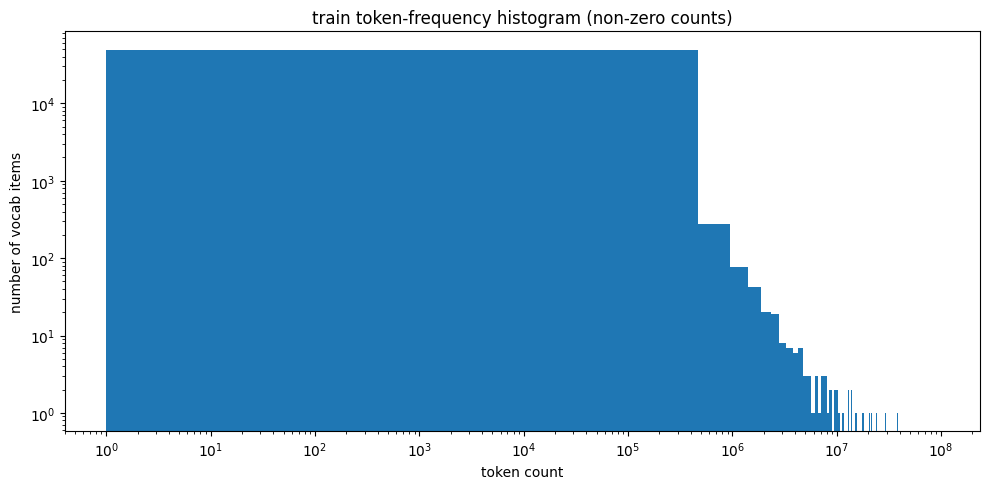

Most frequent tokens
token_id         count       share  token
      13    94,231,684    3.81436%  .
      11    90,498,558    3.66325%  ,
     262    83,679,665    3.38723%   the
     198    52,560,310    2.12756%  \n
     290    50,865,461    2.05896%   and
     284    49,274,825    1.99457%   to
     286    45,751,406    1.85195%   of
     257    38,167,082    1.54495%   a
     287    29,543,968    1.19590%   in
      12    24,342,374    0.98534%  -
     447    21,647,234    0.87625%  \ufffd
     318    20,649,617    0.83587%   is
     329    18,301,121    0.74080%   for
     326    17,622,293    0.71332%   that
     247    15,330,133    0.62054%  \ufffd
     345    13,782,774    0.55791%   you
     351    13,692,550    0.55425%   with
     319    13,173,901    0.53326%   on
     314    12,836,558    0.51961%   I
     340    11,703,980    0.47376%   it

Least frequent tokens (including zero-count tokens)
token_id         count       share  token
   39253             0    0.00000%   

counting: 100%|██████████| 1/1 [00:00<00:00, 15.79it/s]

elapsed: 0.06s
counted tokens: 19,922,944
non-zero vocab items: 49,415 / 50,257
zero-frequency vocab items: 842


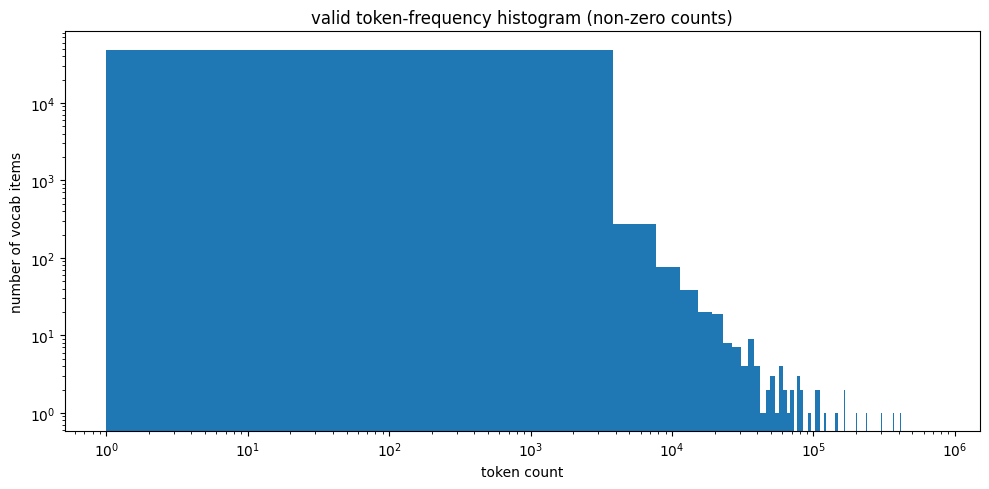

Most frequent tokens
token_id         count       share  token
      13       763,849    3.83402%  .
      11       734,409    3.68625%  ,
     262       677,171    3.39895%   the
     198       421,165    2.11397%  \n
     290       411,862    2.06727%   and
     284       395,471    1.98500%   to
     286       368,062    1.84743%   of
     257       304,629    1.52904%   a
     287       237,541    1.19230%   in
      12       200,439    1.00607%  -
     447       167,652    0.84150%  \ufffd
     318       166,055    0.83349%   is
     329       148,006    0.74289%   for
     326       142,155    0.71352%   that
     247       118,984    0.59722%  \ufffd
     351       109,574    0.54999%   with
     345       109,149    0.54786%   you
     319       106,449    0.53430%   on
     314       103,347    0.51873%   I
     340        93,462    0.46912%   it

Least frequent tokens (including zero-count tokens)
token_id         count       share  token
   17174             0    0.00000%  *

In [5]:
tokenizer = tiktoken.get_encoding(TOKENIZER_NAME)
results = {}

for split_name in SPLITS_TO_ANALYZE:
    meta = split_meta["splits"][split_name]
    print(f"\n=== {split_name.upper()} ===")
    print(
        f"token span: [{meta['start']:,}, {meta['stop']:,}) | "
        f"used_tokens={meta['used_tokens']:,} | batches={meta['num_batches']:,} | "
        f"dropped_tokens={meta['dropped_tokens']:,}"
    )

    counts, elapsed = count_tokens_for_span(
        split_meta["ds_path"],
        meta["start"],
        meta["stop"],
        split_meta["vocab_size"],
        chunk_tokens=CHUNK_TOKENS,
    )

    total_tokens = int(counts.sum())
    zero_ids = np.flatnonzero(counts == 0)
    nonzero_ids = np.flatnonzero(counts > 0)
    sorted_ids = np.argsort(counts)
    top_ids = sorted_ids[-TOP_K:][::-1]
    least_ids = sorted_ids[:BOTTOM_K]
    rare_nonzero_ids = nonzero_ids[np.argsort(counts[nonzero_ids])[:BOTTOM_K]]

    print(f"elapsed: {elapsed:,.2f}s")
    print(f"counted tokens: {total_tokens:,}")
    print(f"non-zero vocab items: {len(nonzero_ids):,} / {len(counts):,}")
    print(f"zero-frequency vocab items: {len(zero_ids):,}")

    plot_frequency_histogram(split_name, counts)

    most_rows = make_rows(top_ids, counts, tokenizer, total_tokens)
    least_rows = make_rows(least_ids, counts, tokenizer, total_tokens)
    rare_nonzero_rows = make_rows(rare_nonzero_ids, counts, tokenizer, total_tokens)

    print_rows("Most frequent tokens", most_rows)
    print()
    print_rows("Least frequent tokens (including zero-count tokens)", least_rows)
    print()
    print_rows("Rarest non-zero tokens", rare_nonzero_rows)

    results[split_name] = {
        "counts": counts,
        "most_frequent": most_rows,
        "least_frequent": least_rows,
        "rarest_nonzero": rare_nonzero_rows,
        "num_zero_frequency_tokens": int(len(zero_ids)),
        "elapsed_seconds": float(elapsed),
    }

In [6]:
for split_name in SPLITS_TO_ANALYZE:
    zero_count = results[split_name]["num_zero_frequency_tokens"]
    vocab_size = split_meta["vocab_size"]
    zero_pct = 100.0 * zero_count / vocab_size
    print(
        f"{split_name}: {zero_count:,} / {vocab_size:,} vocab tokens have zero count "
        f"({zero_pct:.4f}%)"
    )


train: 190 / 50,257 vocab tokens have zero count (0.3781%)
valid: 842 / 50,257 vocab tokens have zero count (1.6754%)


In [7]:
for split_name in SPLITS_TO_ANALYZE:
    counts = results[split_name]["counts"]
    small_count = int((counts <= 5).sum())
    vocab_size = split_meta["vocab_size"]
    small_pct = 100.0 * small_count / vocab_size
    print(
        f"{split_name}: {small_count:,} / {vocab_size:,} vocab tokens have count <= 5 "
        f"({small_pct:.4f}%)"
    )


train: 236 / 50,257 vocab tokens have count <= 5 (0.4696%)
valid: 2,666 / 50,257 vocab tokens have count <= 5 (5.3047%)


In [9]:
for split_name in SPLITS_TO_ANALYZE:
    counts = results[split_name]["counts"]
    avg_count = float(counts.mean())
    print(f"{split_name}: average count per vocab token = {avg_count:,.4f}")


train: average count per vocab token = 49,156.2381
valid: average count per vocab token = 396.4213


In [11]:
for split_name in SPLITS_TO_ANALYZE:
    counts = results[split_name]["counts"]
    avg_count = float(counts.mean())
    closest_ids = np.argsort(np.abs(counts - avg_count))[:5]
    print(f"{split_name}: 5 token ids closest to the average count ({avg_count:,.4f})")
    for token_id in closest_ids:
        token_id = int(token_id)
        print(
            f"  token_id={token_id:>5} count={int(counts[token_id]):,} token={token_text(tokenizer, token_id)}"
        )


train: 5 token ids closest to the average count (49,156.2381)
  token_id=11524 count=49,152 token= applying
  token_id=10834 count=49,170 token= speaker
  token_id=12490 count=49,136 token= DVD
  token_id=13229 count=49,177 token= trips
  token_id=10759 count=49,186 token= focusing
valid: 5 token ids closest to the average count (396.4213)
  token_id= 9922 count=396 token= accuracy
  token_id= 1305 count=396 token= Fr
  token_id= 8744 count=396 token= electricity
  token_id= 5984 count=396 token= AD
  token_id= 8085 count=396 token= mm
